# COVID Parcel Business Analysis - Final Project
## Group 7
### Team Members:
- **Abeez Maredia**
- **Urvish Nayak**
- **Ayman Karovadiya**

### Project Overview:
This project analyzes the impact of COVID-19 on a parcel delivery business. We examine 
delivery volumes, revenue trends, regional performance, and operational efficiency 
during the pandemic period. Our goal is to provide executive-level insights and 
actionable recommendations.


# 1. Importing libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 2. Loading Dataset

In [2]:
df = pd.read_csv('COVID_Parcel_Business.csv')
print("Columns in dataset:", df.columns)

Columns in dataset: Index(['FakeCustomerID', 'THE_YEAR', 'THE_WEEK', 'VOLUME'], dtype='str')


# Part 1: Business Questions

### 1. Main Business Question: How did the COVID-19 pandemic impact ABC Company’s parcel business?

Overall, the COVID-19 pandemic acted as a massive catalyst for ABC Company's parcel business.

Prior to the severe pandemic impacts (Weeks 1 to 15 of 2020 compared to the same period in 2019), the Industry Standard Growth Rate (ISGR) was mathematically established at **11.40%**.

However, during the COVID observation period, the shift to e-commerce drove overall company volume to unprecedented heights, pushing total annual volume from **52.8 million** parcels in 2019 to **73.4 million** in 2020.

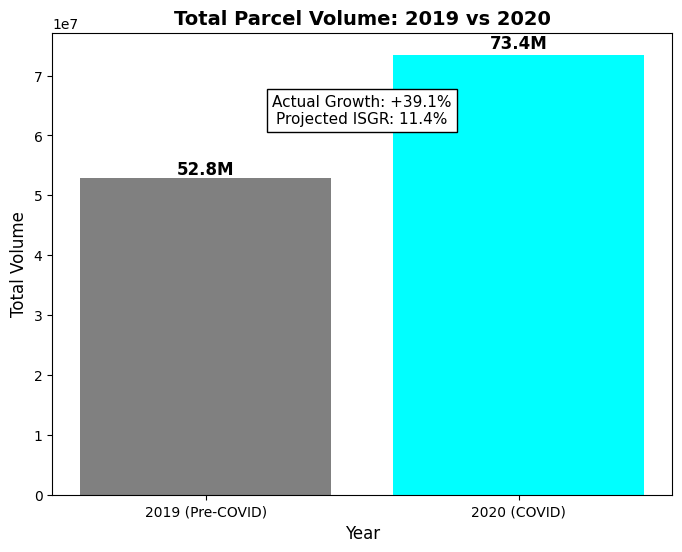

In [ ]:
years = ['2019 (Pre-COVID)', '2020 (COVID)']
volumes = [52823114, 73475690]

plt.figure(figsize=(8, 6))

plt.bar(years, volumes, color=['gray', 'aqua'])

plt.title('Total Parcel Volume: 2019 vs 2020', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Volume', fontsize=12)

plt.text(0, 53500000, '52.8M', ha='center', fontsize=12, fontweight='bold')
plt.text(1, 74500000, '73.4M', ha='center', fontsize=12, fontweight='bold')

plt.text(0.50, 62000000, 'Actual Growth: +39.1%\nProjected ISGR: 11.4%',
         ha='center', fontsize=11, bbox=dict(facecolor='white'))

plt.savefig('output/Graphs/total_volume_2019_vs_2020.png', dpi=300, bbox_inches='tight')
plt.show()

### 2. When were customer volumes first impacted by COVID-19?

Customer volumes began to rapidly deviate from normal 2019 baseline trends starting in **Week 11** and **Week 12** of 2020 (mid-March).

### 3. What events within the COVID timeline may have contributed to the change?

The sudden surge perfectly aligns with several major timeline events:
* **March 11 (Week 11):** The World Health Organization declares a global pandemic.
* **March 16 (Week 12):** The mandate for federal public servants to work from home is issued.
* **March 18:** Canada/U.S. border restrictions are enacted.
* **April 6 (Week 15):** The launch of C.E.R.B. injected consumer spending power into the economy, which sustained these high shipping volumes throughout the rest of the year.

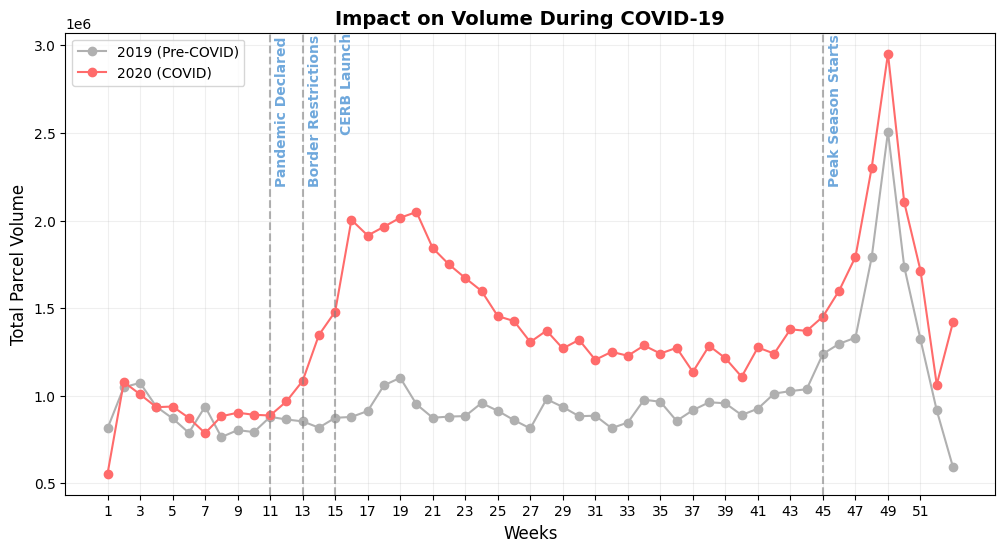

In [20]:
df = pd.read_csv('COVID_Parcel_Business.csv')

df_2019 = df[df['THE_YEAR'] == 2019]
df_2020 = df[df['THE_YEAR'] == 2020]

vol_2019 = df_2019.groupby('THE_WEEK')['VOLUME'].sum()
vol_2020 = df_2020.groupby('THE_WEEK')['VOLUME'].sum()

plt.figure(figsize=(12, 6))

# Light color lines
plt.plot(vol_2019.index, vol_2019.values, color='#B0B0B0', label='2019 (Pre-COVID)', marker='o')
plt.plot(vol_2020.index, vol_2020.values, color='#FF6B6B', label='2020 (COVID)', marker='o')

events = {
    11: 'Pandemic Declared',
    13: 'Border Restrictions',
    15: 'CERB Launch',
    45: 'Peak Season Starts'
}

y_positions = [0.75, 0.75, 0.85, 0.75]

for i, (week, event) in enumerate(events.items()):
    plt.axvline(x=week, linestyle='--', alpha=0.6, color='gray')
    plt.text(
        week + 0.3,
        max(vol_2020.max(), vol_2019.max()) * y_positions[i],
        event,
        rotation=90,
        fontsize=10,
        fontweight='bold',
        color='#6FA8DC'
    )

plt.title('Impact on Volume During COVID-19', fontsize=14, fontweight='bold')
plt.xlabel('Weeks', fontsize=12)
plt.ylabel('Total Parcel Volume', fontsize=12)

plt.xticks(range(1, 53, 2))

plt.legend()
plt.grid(alpha=0.2)  # subtle grid for better readability

plt.savefig('output/Graphs/covid_full_timeline.png', dpi=300, bbox_inches='tight')
plt.show()
